In [2]:
# Imports
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

import joblib

sns.set_style("whitegrid")

In [3]:
anemia_df = pd.read_csv("../data/anemia.csv")
anemia_df.head()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
0,1,14.9,22.7,29.1,83.7,0
1,0,15.9,25.4,28.3,72.0,0
2,0,9.0,21.5,29.6,71.2,1
3,0,14.9,16.0,31.4,87.5,0
4,1,14.7,22.0,28.2,99.5,0


In [4]:
# Data Preprocessing
anemia_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1421 entries, 0 to 1420
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Gender      1421 non-null   int64  
 1   Hemoglobin  1421 non-null   float64
 2   MCH         1421 non-null   float64
 3   MCHC        1421 non-null   float64
 4   MCV         1421 non-null   float64
 5   Result      1421 non-null   int64  
dtypes: float64(4), int64(2)
memory usage: 66.7 KB


In [5]:
anemia_df.describe()

,Gender,Hemoglobin,MCH,MCHC,MCV,Result
count,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,0.520760,13.412738,22.905630,30.251232,85.523786,0.436312
std,0.499745,1.974546,3.969375,1.400898,9.636701,0.496102
min,0.000000,6.600000,16.000000,27.800000,69.400000,0.000000
25%,0.000000,11.700000,19.400000,29.000000,77.300000,0.000000
50%,1.000000,13.200000,22.700000,30.400000,85.300000,0.000000
75%,1.000000,15.000000,26.200000,31.400000,94.200000,1.000000
max,1.000000,16.900000,30.000000,32.500000,101.600000,1.000000


In [7]:
X = anemia_df.drop("Result", axis=1)
y = anemia_df["Result"]

x_train, x_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [8]:
models = {
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Decision Tree":DecisionTreeClassifier(random_state=42),
    "Random Forest":RandomForestClassifier(random_state=42),
    "Gradient Boosting":GradientBoostingClassifier(random_state=42, learning_rate=0.1),
    "AdaBoost":AdaBoostClassifier(random_state=42, learning_rate=0.1),
    "XGBoost":XGBClassifier(random_state=42,eval_metric='mlogloss')
}

In [9]:
#Benchmark function to evaluate all models using accuracy, precision, recall, and F1 score.
def evaluate_model(model, name):

    model.fit(x_train, y_train)

    train_preds = model.predict(x_train)
    test_preds = model.predict(x_test)

    train_acc = accuracy_score(
        y_train,
        train_preds
    )

    test_acc = accuracy_score(
        y_test,
        test_preds
    )

    precision = precision_score(
        y_test,
        test_preds,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        test_preds,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        test_preds,
        average="weighted"
    )

    return {
        "Model": name,
        "Train Accuracy": round(train_acc,4),
        "Test Accuracy": round(test_acc,4),
        "Precision": round(precision,4),
        "Recall": round(recall,4),
        "F1 Score": round(f1,4)
    }

In [10]:
results = []

for name, model in models.items():

    results.append(
        evaluate_model(
            model,
            name
        )
    )

results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.0000,1.000,1.0000,1.000,1.000
2,Random Forest,1.0000,1.000,1.0000,1.000,1.000
4,AdaBoost,1.0000,1.000,1.0000,1.000,1.000
3,Gradient Boosting,1.0000,1.000,1.0000,1.000,1.000
5,XGBoost,1.0000,1.000,1.0000,1.000,1.000
0,Logistic Regression,0.9886,0.986,0.9864,0.986,0.986


In [11]:
# Hyperparameter tuning - decision tree 
dt_params = {
    "max_depth":[3,5,7,10,15,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini", "entropy"]
}

# random forest
rf_params = {
    "n_estimators":[100,200,300],
    "max_depth":[5,10,15,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "criterion":["gini", "entropy"]
}

In [12]:
dt_grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=dt_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

dt_grid.fit(
    x_train,
    y_train
)

best_dt = dt_grid.best_estimator_

print(dt_grid.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [13]:
results.append(
    evaluate_model(
        best_dt,
        "Decision Tree Tuned"
    )
)

In [14]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(
    x_train,
    y_train
)

best_rf = rf_grid.best_estimator_

print(
    rf_grid.best_params_
)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [15]:
results.append(
    evaluate_model(
        best_rf,
        "Random Forest Tuned"
    )
)

In [16]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score
1,Decision Tree,1.0000,1.000,1.0000,1.000,1.000
2,Random Forest,1.0000,1.000,1.0000,1.000,1.000
3,Gradient Boosting,1.0000,1.000,1.0000,1.000,1.000
4,AdaBoost,1.0000,1.000,1.0000,1.000,1.000
6,Decision Tree Tuned,1.0000,1.000,1.0000,1.000,1.000
5,XGBoost,1.0000,1.000,1.0000,1.000,1.000
7,Random Forest Tuned,1.0000,1.000,1.0000,1.000,1.000
0,Logistic Regression,0.9886,0.986,0.9864,0.986,0.986


In [17]:
results_df["Overfitting Gap"] = (
    results_df["Train Accuracy"] -
    results_df["Test Accuracy"]
)

results_df.sort_values(
    by="Overfitting Gap",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,Overfitting Gap
0,Logistic Regression,0.9886,0.986,0.9864,0.986,0.986,0.0026
1,Decision Tree,1.0000,1.000,1.0000,1.000,1.000,0.0000
2,Random Forest,1.0000,1.000,1.0000,1.000,1.000,0.0000
3,Gradient Boosting,1.0000,1.000,1.0000,1.000,1.000,0.0000
4,AdaBoost,1.0000,1.000,1.0000,1.000,1.000,0.0000
5,XGBoost,1.0000,1.000,1.0000,1.000,1.000,0.0000
6,Decision Tree Tuned,1.0000,1.000,1.0000,1.000,1.000,0.0000
7,Random Forest Tuned,1.0000,1.000,1.0000,1.000,1.000,0.0000


In [21]:
final_model = LogisticRegression(max_iter=500)
final_model.fit(
    x_train,
    y_train
)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",500
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [22]:
preds = final_model.predict(x_test)

print(
    classification_report(
        y_test,
        preds
    )
)

              precision    recall  f1-score   support

           0       1.00      0.98      0.99       161
           1       0.97      1.00      0.98       124

    accuracy                           0.99       285
   macro avg       0.98      0.99      0.99       285
weighted avg       0.99      0.99      0.99       285



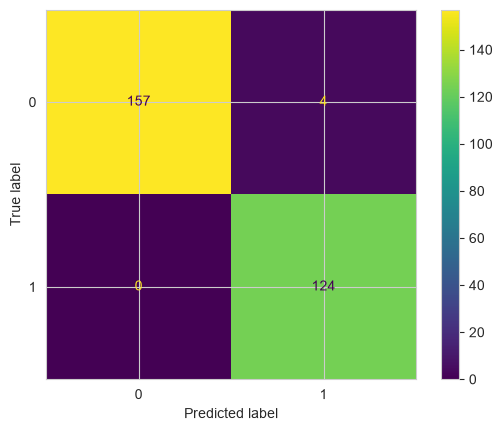

In [23]:
cm = confusion_matrix(
    y_test,
    preds
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

In [24]:
joblib.dump(
    final_model,
    "../models/anemia_model.pkl"
)

print("Model Saved")

Model Saved
